Creating of datasets (dimensionless, no_multicoll) with polinomial features

# Libraries

In [16]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.preprocessing import PolynomialFeatures as pf

import seaborn as sns
import matplotlib.pyplot as plt

# Datasets analysis

In [2]:
path_data = Path('../data/')
xlsxs = ['df_modelling_dimensionless', 'df_modelling_no_multicollinearity']

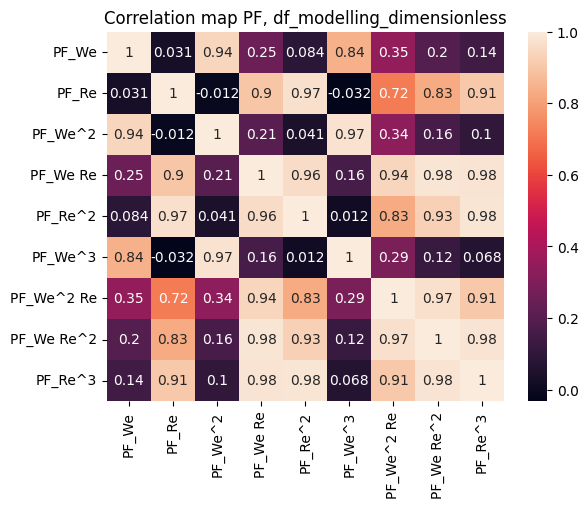

Features with correlation <= 0.8
Index(['PF_We', 'PF_Re'], dtype='object')


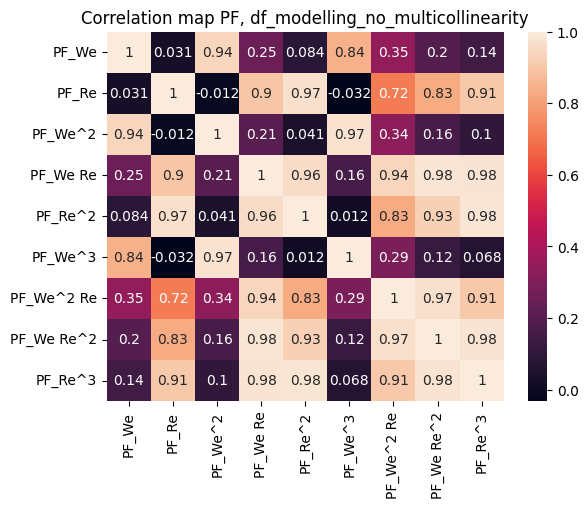

Features with correlation <= 0.8
Index(['PF_We', 'PF_Re'], dtype='object')


In [49]:
for filename in xlsxs:
    df = pd.read_excel(path_data / f'{filename}.xlsx')

    poly = pf(3)
    poly_data = poly.fit_transform(df[['We', 'Re']])
    poly_features = [f'PF_{x}' for x in poly.get_feature_names_out()]
    df_pf = pd.DataFrame(data=poly_data, columns=poly_features).iloc[:, 1:]
    sns.heatmap(df_pf.corr(), annot=True, fmt='.2g')
    plt.title(f'Correlation map PF, {filename}')
    plt.show()

    # Creating correlation matrix
    cor_matrix = df_pf.corr().abs()
    # Selecting upper triangle of correlation matrix
    upper_tri = cor_matrix.where(np.triu(np.ones(cor_matrix.shape),
                                        k=1).astype(bool))
    # Finding index of feature columns with correlation greater than 0.8
    to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.8)]
    # Droping Marked Features
    df1 = df_pf.drop(columns=to_drop, axis=1)
    print(f'Features with correlation <= 0.8\n{df1.columns}')